# Analiza danych maratońskich ze Stravy
Celem tego projektu jest zbadanie związku między treningiem w ostatnich 4 tygodniach przed startem a końcowym czasem maratonu. 
Korzystam z danych 87 biegaczy amatorów i zawodowców.

In [45]:
import pandas as pd

df = pd.read_csv('MarathonData.csv')


In [46]:
df

,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,NaN,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,NaN,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,NaN,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,NaN,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,NaN,1.36,2.74,A
...,...,...,...,...,...,...,...,...,...,...
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,NaN,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,NaN,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,NaN,2.05,3.95,D


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             87 non-null     int64  
 1   Marathon       87 non-null     object 
 2   Name           87 non-null     object 
 3   Category       81 non-null     object 
 4   km4week        87 non-null     float64
 5   sp4week        87 non-null     float64
 6   CrossTraining  13 non-null     object 
 7   Wall21         87 non-null     object 
 8   MarathonTime   87 non-null     float64
 9   CATEGORY       87 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 6.9+ KB


In [48]:
df.isnull().sum()
df

,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,NaN,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,NaN,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,NaN,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,NaN,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,NaN,1.36,2.74,A
...,...,...,...,...,...,...,...,...,...,...
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,NaN,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,NaN,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,NaN,2.05,3.95,D


## Przygotowanie danych (Data Cleaning)
W tej sekcji zajmuję się brakującymi wartościami oraz usuwam błędy grubości (outliers). 
Zidentyfikowałam rekord z nierealną prędkością treningową (>11,000 km/h), który zniekształcał statystyki.

In [49]:
df['CrossTraining'] = df['CrossTraining'].fillna(0)

In [50]:
df['Category'] = df['Category'].fillna('Unknown')

In [51]:
df = df.rename(columns={
    'Category': 'AgeGroup',
    'CATEGORY': 'PerformanceGroup'
})

In [52]:
df

,id,Marathon,Name,AgeGroup,km4week,sp4week,CrossTraining,Wall21,MarathonTime,PerformanceGroup
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,0,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,0,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,0,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,0,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,0,1.36,2.74,A
...,...,...,...,...,...,...,...,...,...,...
82,83,Prague17,Stefano Vegliani,M55,50.0,10.830325,0,2.02,3.93,D
83,84,Prague17,Andrej Madliak,M40,33.6,10.130653,ciclista 3h,1.94,3.93,D
84,85,Prague17,Yoi Ohsako,M40,55.4,11.043189,0,1.94,3.94,D
85,86,Prague17,Simon Dunn,M45,33.2,11.066667,0,2.05,3.95,D


In [53]:
df.isnull().sum()

id                  0
Marathon            0
Name                0
AgeGroup            0
km4week             0
sp4week             0
CrossTraining       0
Wall21              0
MarathonTime        0
PerformanceGroup    0
dtype: int64

In [54]:
# Sprawdzam średni czas maratonu dla każdej grupy wynikowej (A, B, C, D)
mean_time = df.groupby('PerformanceGroup')['MarathonTime'].mean()
print("Średni czas w grupach:")
print(mean_time)

# Sprawdzam ile kilometrów średnio biegały osoby z poszczególnych grup wiekowych
mean_km = df.groupby('AgeGroup')['km4week'].mean()
print("\nŚredni dystans (4 tyg) wg kategorii wiekowej:")
print(mean_km)

Średni czas w grupach:
PerformanceGroup
A    2.815714
B    3.216071
C    3.534286
D    3.844706
Name: MarathonTime, dtype: float64

Średni dystans (4 tyg) wg kategorii wiekowej:
AgeGroup
M40        57.440000
M45        67.126667
M50        76.800000
M55        73.700000
MAM        59.455000
Unknown    58.250000
WAM        74.925000
Name: km4week, dtype: float64


In [55]:
print("Rekordy z nierealną prędkością:")
print(df[df['sp4week'] > 100])

# Tworzę nową tabelę df_clean, która zawiera tylko realne dane
df_clean = df[df['sp4week'] < 100].copy()

# Weryfikacja
print(f"\nLiczba wierszy przed czyszczeniem: {len(df)}")
print(f"Liczba wierszy po usunięciu błędów: {len(df_clean)}")

Rekordy z nierealną prędkością:
    id  Marathon         Name AgeGroup  km4week  sp4week CrossTraining Wall21  \
81  82  Prague17  Nathan Khan      MAM     35.6  11125.0             0   2.05   

    MarathonTime PerformanceGroup  
81          3.92                D  

Liczba wierszy przed czyszczeniem: 87
Liczba wierszy po usunięciu błędów: 86


## Wizualizacja i wnioski statystyczne
Wykorzystuję bibliotekę **Seaborn** do wizualizacji rozkładów prędkości oraz korelacji. 
Szczególnie interesuje mnie wpływ wskaźnika `Wall21` na ostateczny wynik.

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

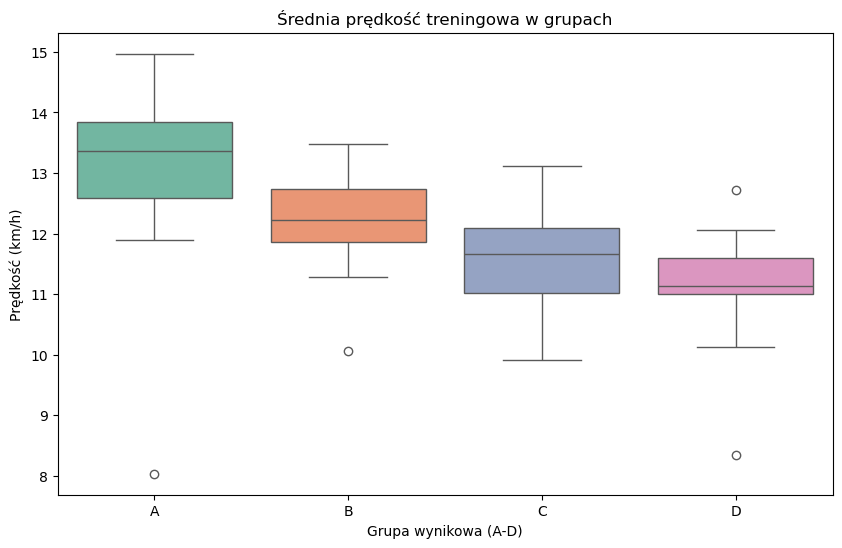

In [57]:
# Filtrujemy dane i zostawiamy tylko te, gdzie sp4week jest realne (poniżej 100 km/h)
df_clean = df[df['sp4week'] < 100]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='PerformanceGroup', y='sp4week', hue='PerformanceGroup', palette='Set2')

plt.title('Średnia prędkość treningowa w grupach')
plt.xlabel('Grupa wynikowa (A-D)')
plt.ylabel('Prędkość (km/h)')
plt.show()

In [58]:
# Zamieniam Wall21 na liczby
df_clean['Wall21'] = pd.to_numeric(df_clean['Wall21'], errors='coerce')

df_clean = df_clean.dropna(subset=['Wall21'])

correlation = df_clean[['km4week', 'sp4week', 'Wall21', 'MarathonTime']].corr()
print(correlation['MarathonTime'])

km4week        -0.623238
sp4week        -0.639466
Wall21          0.968751
MarathonTime    1.000000
Name: MarathonTime, dtype: float64


C:\Users\Patrycja\AppData\Local\Temp\ipykernel_7072\2101778185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Wall21'] = pd.to_numeric(df_clean['Wall21'], errors='coerce')


In [59]:
# Sprawdzam korelację między treningiem a wynikiem
correlation = df_clean[['km4week', 'sp4week', 'Wall21', 'MarathonTime']].corr()
print(correlation['MarathonTime'])

km4week        -0.623238
sp4week        -0.639466
Wall21          0.968751
MarathonTime    1.000000
Name: MarathonTime, dtype: float64


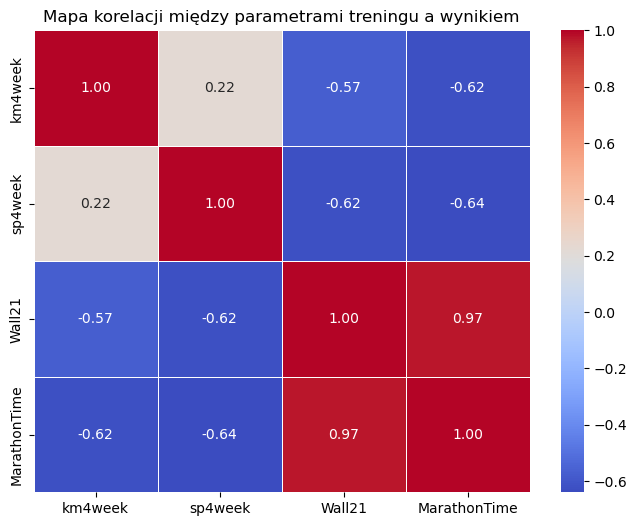

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa korelacji między parametrami treningu a wynikiem')
plt.show()

**Wniosek:** Korelacja rzędu -0.64 dla prędkości treningowej potwierdza, że jest to jeden z najsilniejszych predyktorów wyniku maratońskiego w tym zbiorze danych.

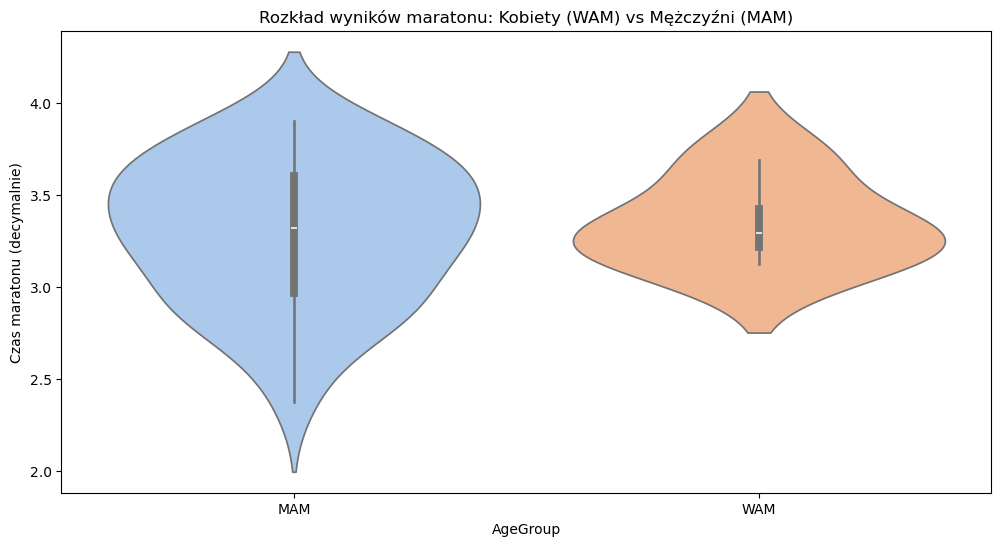

In [65]:
plt.figure(figsize=(12, 6))

gender_df = df_clean[df_clean['AgeGroup'].isin(['MAM', 'WAM'])]

sns.violinplot(data=gender_df, x='AgeGroup', y='MarathonTime', hue='AgeGroup', palette='pastel', legend=False)
plt.title('Rozkład wyników maratonu: Kobiety (WAM) vs Mężczyźni (MAM)')
plt.ylabel('Czas maratonu (decymalnie)')
plt.show()